<a href="https://colab.research.google.com/github/JamesSembukuttiarachchi/rain_in_australia/blob/feat%2Fusing-logistic-regression/01_logistic_regression_weatherAUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Import Libraries**

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### **2. Load Dataset**

In [20]:

# Make sure dataset is uploaded to /content in Colab
df = pd.read_csv('/content/weatherAUS_balanced.csv')

print("Original shape:", df.shape)
df.head()

Original shape: (220632, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0.0,0.0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0.0,0.0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0.0,0.0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0.0,0.0


### **3. Basic Cleaning**

In [21]:

df = df.copy()

# Drop rows where target is missing
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)

# Ensure target is binary (0/1)
df["RainTomorrow"] = df["RainTomorrow"].astype(int)

# Handle RainToday safely (works for both 0/1 or Yes/No)
if df["RainToday"].dtype == "object":
    df["RainToday"] = df["RainToday"].map({"No": 0, "Yes": 1})

# Fill NaN values in RainToday with 0 before converting to int
df["RainToday"] = df["RainToday"].fillna(0).astype(int)

### **4. Feature Engineering**

In [22]:

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear

# Drop original date column
df = df.drop(columns=["Date"])

# Remove low-impact noisy feature
if 'Day' in df.columns:
    df = df.drop(columns=['Day'])


### **5. Basic Analysis**


Cleaned shape: (220632, 25)

Target distribution:
RainTomorrow
0    110316
1    110316
Name: count, dtype: int64

Target proportions:
RainTomorrow
0    0.5
1    0.5
Name: proportion, dtype: float64

Top missing columns (%):
Sunshine         47.51
Evaporation      43.24
Cloud3pm         38.80
Cloud9am         36.87
Pressure3pm       9.86
Pressure9am       9.85
WindGustDir       7.02
WindGustSpeed     6.96
WindDir9am        6.68
WindDir3pm        2.92
dtype: float64


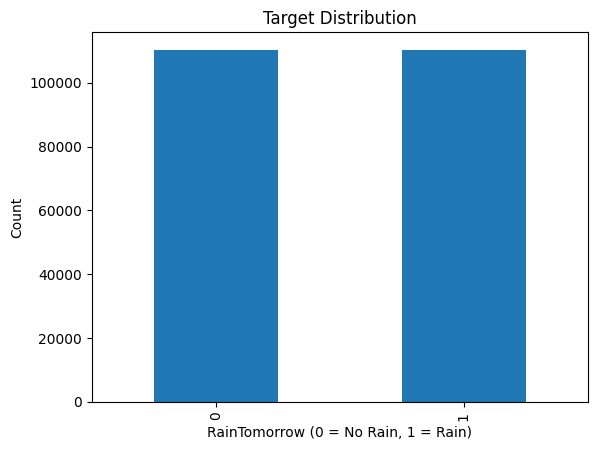

In [23]:

print("\nCleaned shape:", df.shape)

print("\nTarget distribution:")
print(df["RainTomorrow"].value_counts())

print("\nTarget proportions:")
print(df["RainTomorrow"].value_counts(normalize=True).round(4))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

print("\nTop missing columns (%):")
print(missing_pct.head(10).round(2))

# Plot target distribution
ax = df["RainTomorrow"].value_counts().plot(kind="bar", title="Target Distribution")
ax.set_xlabel("RainTomorrow (0 = No Rain, 1 = Rain)")
ax.set_ylabel("Count")
plt.show()


### **6. Split Features & Target**

In [24]:

X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

### **7. Identify Column Types**

In [25]:

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


### **8. Preprocessing Pipeline**

In [26]:

# Handle missing values + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Handle categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


### **9. Feature Selection (Optimization)**

In [27]:

feature_selector = SelectKBest(score_func=f_classif, k=20)


### **10. Train-Test Split**

In [28]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### **11. Model (Optimized Logistic Regression)**

In [29]:

model = LogisticRegression(
    max_iter=500,
    solver='liblinear',
    C=1.0
)


### **12. Full Pipeline**

In [30]:

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', model)
])


### **13. Train Model**

In [31]:

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       '...3pm', 'RainToday'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], dtype='object'))])),
                ('feature_selection', SelectKBest(k=20)),
                ('classifier',
                 LogisticRegression(max_iter=500, solver='liblinear'))])

### **14. Predictions**

In [32]:

y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 1]

### **15. Evaluation**

In [33]:

print("\n===== MODEL PERFORMANCE =====")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_probs))


===== MODEL PERFORMANCE =====
Accuracy: 0.7813583520293698

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.79      0.78     21960
           1       0.79      0.77      0.78     22167

    accuracy                           0.78     44127
   macro avg       0.78      0.78      0.78     44127
weighted avg       0.78      0.78      0.78     44127


Confusion Matrix:

[[17444  4516]
 [ 5132 17035]]

ROC-AUC Score: 0.8645543180952207


### **16. Confusion Matrix Plot**

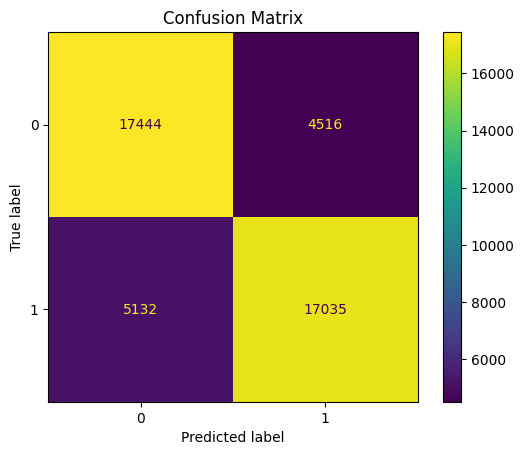

In [34]:

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()